Problem statement:
Employee attrition is increasing, leading to:


*   High hiring & training costs
*   Loss of experienced talent
*   Reduced team productivity

Build a machine learning solution to:



*  Predict whether an employee will     leave (Attrition: Yes/No)
*   Identify key factors driving attrition

*  Provide actionable insights to HR



# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Load the dataset

In [ ]:
df=pd.read_csv("/content/HR-Employee_Attrition.csv")

In [ ]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


#Basic datacheck

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:



df.shape

(1470, 35)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [ ]:
#Check for null values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Comment:There are no null values

In [ ]:
#check for duplicate value
df.duplicated().sum()

np.int64(0)

Comment:There are no duplicate values in the dataset

In [ ]:
#categorical and numerical columns
cat=df.select_dtypes(include='object').columns
num=df.select_dtypes(exclude='object').columns

Comment:Divided dataset into categorical and numerical columns

In [ ]:
cat

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [ ]:
num

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [ ]:
#check for errror values
for i in cat:
  print(df[i].value_counts())
  print("----"*50)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
EducationField
Life Sciences       606
Medical             464
Marketing           159
Tech

Comment:There are no error values

In [ ]:
#outlier detection
for col in num:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  IQR=q3-q1
  lb=q1-1.5*IQR
  ub=q3+1.5*IQR
  outliers=df[(df[col]<lb)|(df[col]>ub)]
  df_iqr=df[(df[col]>=lb)&(df[col]<=ub)]

print("Original_shape:",df.shape)
print("After removal:",df_iqr.shape)


Original_shape: (1470, 35)
After removal: (1456, 35)


Comment:There are 14 ouliers in the dataset

# Univariate analysis

#Age Distribution

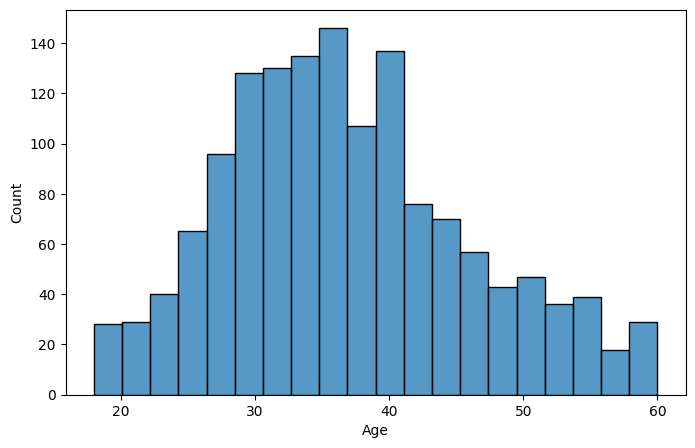

,Age
count,1470.000000
mean,36.923810
std,9.135373
min,18.000000
25%,30.000000
50%,36.000000
75%,43.000000
max,60.000000


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_iqr['Age'],bins=20)
plt.show()

# # Summary
df['Age'].describe()

Comment:Employees age  range between 18 to 60 yrs.Largest group falls under the range between 30 to 40yrs. Age distribution is concentrated in mid‑career professionals, which could influence attrition, promotion rates, and salary structures.

Count = 1470  
There are 1,470 employees in the dataset with recorded ages.

Mean = 36.92  
The average age of employees is about 37 years.

Std (Standard Deviation) = 9.13  
Ages vary by about 9 years around the mean, showing moderate spread.

Min = 18  
The youngest employee is 18 years old.

25% (Q1) = 30  
25% of employees are aged 30 or younger.

50% (Median) = 36  
Half of employees are younger than 36, half are older.

75% (Q3) = 43  
75% of employees are aged 43 or younger.

Max = 60  
The oldest employee is 60 years old.

#Monthly income spread

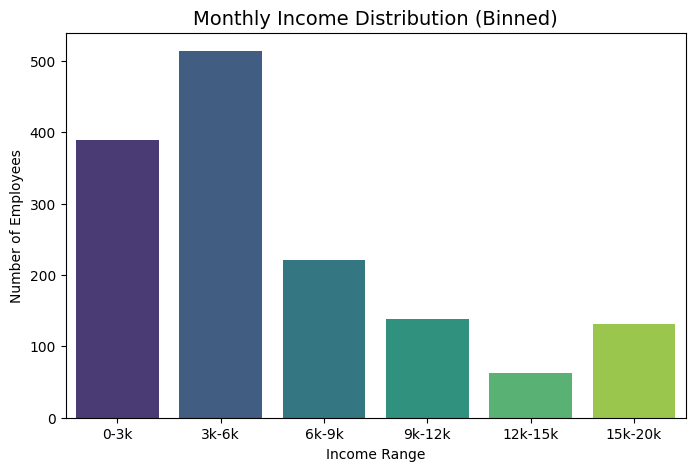

In [ ]:
# Define bins and labels
bins = [0, 3000, 6000, 9000, 12000, 15000, 20000]
labels = ['0-3k', '3k-6k', '6k-9k', '9k-12k', '12k-15k', '15k-20k']

# Create IncomeRange column
df_iqr['IncomeRange'] = pd.cut(df_iqr['MonthlyIncome'], bins=bins, labels=labels)

# Plot bar chart
plt.figure(figsize=(8,5))
sns.countplot(x='IncomeRange', data=df_iqr, palette="viridis")
plt.title("Monthly Income Distribution (Binned)", fontsize=14)
plt.xlabel("Income Range")
plt.ylabel("Number of Employees")
plt.show()

Comment:
0–3k: Around 400 employees

3k–6k: The largest group, around 520 employees

6k–9k: About 230 employees

9k–12k: Roughly 140 employees

12k–15k: Smallest group, around 60 employees

15k–20k: About 130 employees.
Most employees earn below 6k per month.There is a sharp drop at 6k,showing fewer people with higher salaries.The small cluster at 12k-15k and modrate distribution at 15k-20k.

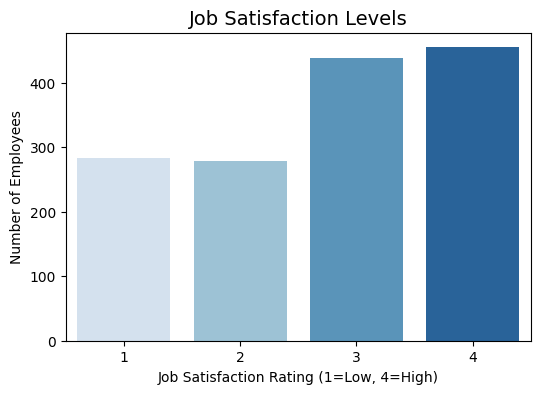

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='JobSatisfaction', data=df_iqr, order=[1,2,3,4], palette="Blues")
plt.title("Job Satisfaction Levels", fontsize=14)
plt.xlabel("Job Satisfaction Rating (1=Low, 4=High)")
plt.ylabel("Number of Employees")
plt.show()

Comment:
The majority of employees report high satisfaction (3 or 4) — together that’s about 900 out of 1470 employees.

A significant minority  fall into low satisfaction (1 or 2).

This split suggests that while overall morale is good, there’s a sizeable group of employees who may be disengaged or at risk of attrition.

#convert categorical col to numerical

In [ ]:
le_d={}

In [ ]:
from sklearn.preprocessing import LabelEncoder
for col in cat:
  le=LabelEncoder()
  df_iqr[col]=le.fit_transform(df_iqr[col])#It will convert  all categorical col to numerical
 # print(f"df_iqr[{col}]:",df_iqr[col])
  le_d[col]=le# asving the encoding for future use


In [ ]:
le_d

{'Attrition': LabelEncoder(),
 'BusinessTravel': LabelEncoder(),
 'Department': LabelEncoder(),
 'EducationField': LabelEncoder(),
 'Gender': LabelEncoder(),
 'JobRole': LabelEncoder(),
 'MaritalStatus': LabelEncoder(),
 'Over18': LabelEncoder(),
 'OverTime': LabelEncoder()}

In [ ]:
df_iqr

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomeRange
0,41,1,2,1102,2,1,2,1,1,1,...,80,0,8,0,1,6,4,0,5,0-3k
1,49,0,1,279,1,8,1,1,1,2,...,80,1,10,3,3,10,7,1,7,0-3k
2,37,1,2,1373,1,2,2,4,1,4,...,80,0,7,3,3,0,0,0,0,0-3k
3,33,0,1,1392,1,3,4,1,1,5,...,80,0,8,3,3,8,7,3,0,0-3k
4,27,0,2,591,1,2,1,3,1,7,...,80,1,6,3,3,2,2,2,2,0-3k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,1,884,1,23,2,3,1,2061,...,80,1,17,3,3,5,2,0,3,15k-20k
1466,39,0,2,613,1,6,1,3,1,2062,...,80,1,9,5,3,7,7,1,7,15k-20k
1467,27,0,2,155,1,4,3,1,1,2064,...,80,1,6,0,3,6,2,0,3,15k-20k
1468,49,0,1,1023,2,2,3,3,1,2065,...,80,0,17,3,2,9,6,0,8,15k-20k


# Bivariate analysis.

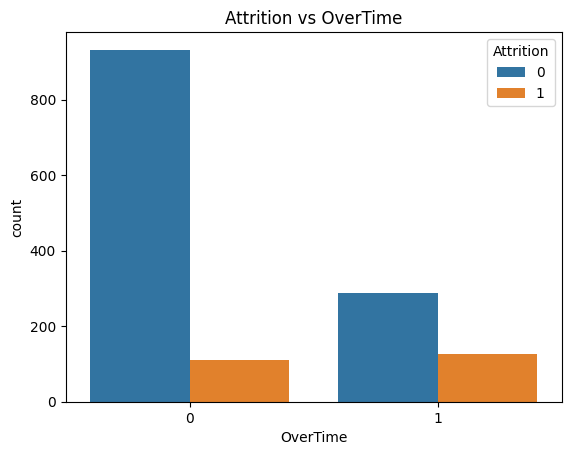

In [ ]:
sns.countplot(x='OverTime', hue='Attrition', data=df_iqr)
plt.title("Attrition vs OverTime")
plt.show()

Comment:
OverTime = Yes: Employees who work overtime have noticeably higher attrition compared to those who don’t.

OverTime = No: The majority of employees who don’t work overtime stay with the company.

This confirms a strong correlation: overtime work increases the likelihood of leaving.

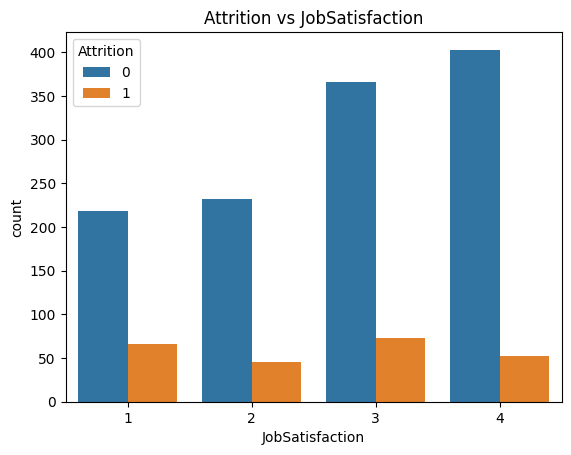

In [ ]:
sns.countplot(x='JobSatisfaction',hue='Attrition',data=df_iqr)
plt.title("Attrition vs JobSatisfaction")
plt.show()

Comment:At low satisfaction levels (1 and 2), attrition counts are noticeably higher.

At higher satisfaction levels (3 and 4), most employees stay, with attrition dropping sharply.

This confirms a clear trend: the happier employees are in their jobs, the less likely they are to leave.

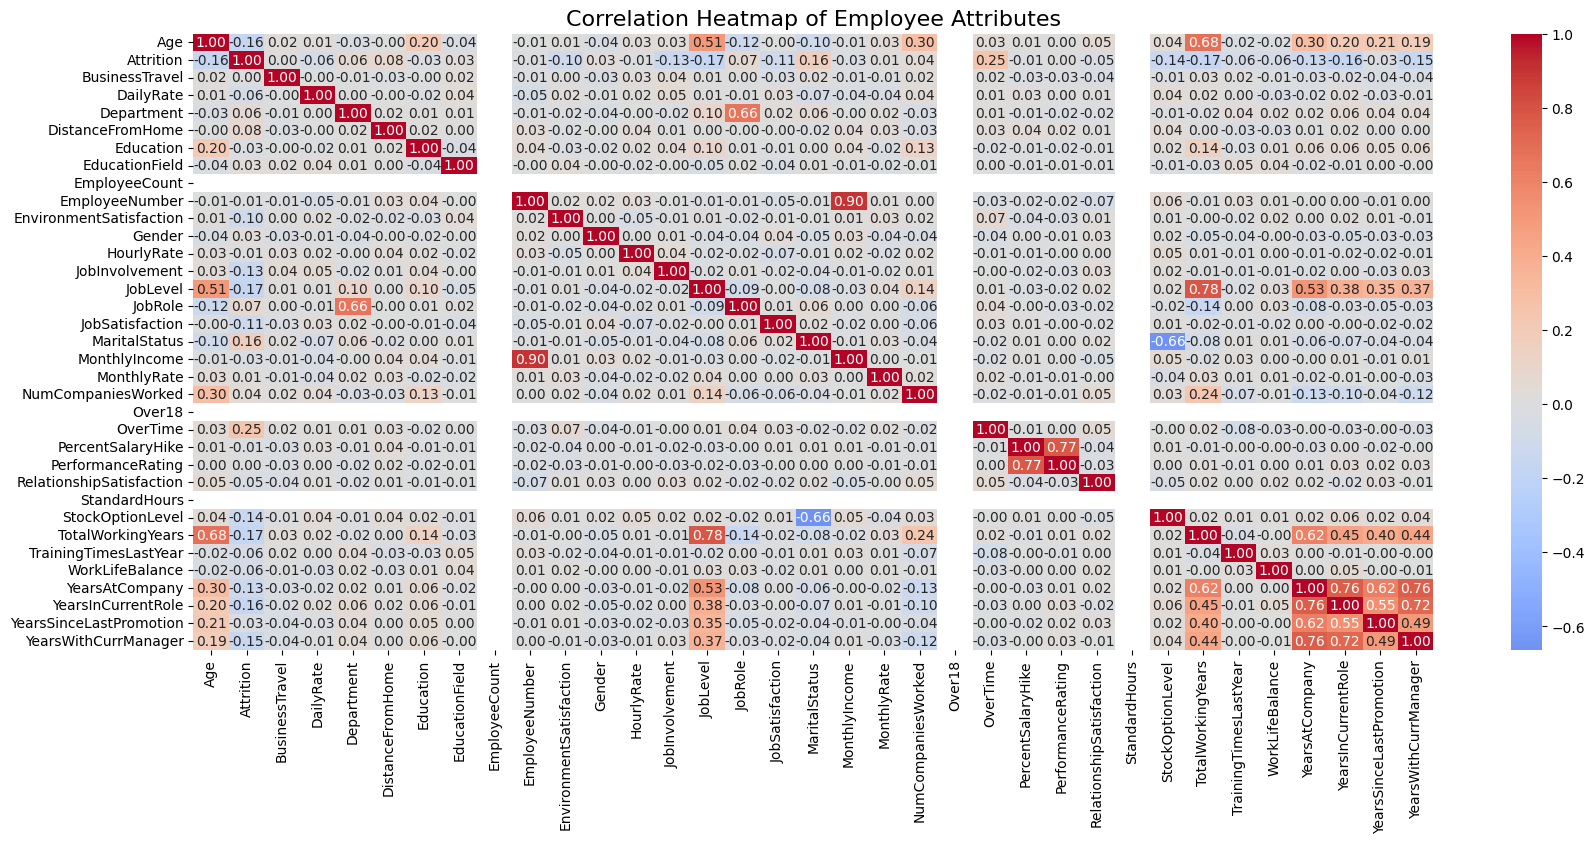

In [ ]:
plt.figure(figsize=(20, 8))
sns.heatmap(df_iqr.drop('IncomeRange', axis=1).corr(),
            annot=True,
            cmap="coolwarm",
            center=0,
            fmt=".2f")
plt.title("Correlation Heatmap of Employee Attributes", fontsize=16)
plt.show()

Comment:
JobLevel ↔ MonthlyIncome (0.95): Higher job levels are almost perfectly associated with higher monthly income.

YearsAtCompany ↔ YearsInCurrentRole (0.76): Employees who have been at the company longer tend to stay longer in their current role.

TotalWorkingYears ↔ Age (0.68): Older employees naturally have more total working years.
Attrition has relatively weak correlations with most features.


In [ ]:
df_iqr.drop('IncomeRange',axis=1,inplace=True)

#Ml model building

In [ ]:
X=df_iqr.drop(['Attrition','EmployeeNumber','EmployeeCount','Over18','StandardHours'],axis=1)
y=df_iqr['Attrition']

In [ ]:
pd.set_option('display.max_columns',None)
pd.set_option('display.width',None)
X

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,2,1102,2,1,2,1,2,0,94,3,2,7,4,2,1009,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,1,279,1,8,1,1,3,1,61,2,2,6,2,1,1051,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,2,1373,1,2,2,4,4,1,92,2,1,2,3,2,1052,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,1,1392,1,3,4,1,4,0,56,3,1,6,3,1,1081,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,2,591,1,2,1,3,1,1,40,3,1,2,2,1,1091,16632,9,0,12,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,1,884,1,23,2,3,3,1,41,4,2,2,4,1,19859,12290,4,0,17,3,3,1,17,3,3,5,2,0,3
1466,39,2,613,1,6,1,3,4,1,42,2,3,0,1,1,19926,21457,4,0,15,3,1,1,9,5,3,7,7,1,7
1467,27,2,155,1,4,3,1,2,1,87,4,2,4,2,1,19943,5174,1,1,20,4,2,1,6,0,3,6,2,0,3
1468,49,1,1023,2,2,3,3,4,1,63,2,2,7,2,1,19973,13243,2,0,14,3,4,0,17,3,2,9,6,0,8


In [ ]:
y

,Attrition
0,1
1,0
2,1
3,0
4,0
...,...
1465,0
1466,0
1467,0
1468,0


In [ ]:
#Divide  data into train and test data

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7)


In [ ]:
y_train=y_train.squeeze()#converted y_train to 1D array

Comment:Divided dataset into train data and test date to train n test the model.

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1019, 30), (437, 30), (1019,), (437,))

#Importing multiple models


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
#Model initialization
lr=LogisticRegression()
nb=GaussianNB()
rf=RandomForestClassifier()
dt=DecisionTreeClassifier()

Comment: Initialized the model

In [ ]:
# Apply Label Encoding to categorical columns in X_train and X_test
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = le_d[col].transform(X_train[col])
    X_test[col] = le_d[col].transform(X_test[col])

# Training the model
lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier()

Comment:Trained the model using X_train Nd y_train data

In [ ]:
#Model Evaluation
lr_pred = lr.predict(X_test)
nb_pred=nb.predict(X_test)
rf_pred=rf.predict(X_test)
dt_pred=dt.predict(X_test)

Comment:Predicted the y values for X_test by passing X_test data.

In [ ]:
#confusion matrix for all models
print("Confusion matrix for Naive Bayes:")
print(metrics.confusion_matrix(y_test,nb_pred))

Confusion matrix for Naive Bayes:
[[336  33]
 [ 36  32]]


In [ ]:
print("Confusion matrix for Random Forest:")
print(metrics.confusion_matrix(y_test,rf_pred))

Confusion matrix for Random Forest:
[[367   2]
 [ 59   9]]


In [ ]:
print("Confusion matrix for Decision Tree:")
print(metrics.confusion_matrix(y_test,dt_pred))

Confusion matrix for Decision Tree:
[[329  40]
 [ 48  20]]


In [ ]:
#Check accuracy of each model
lr_acc = metrics.accuracy_score(y_test, lr_pred)
nb_acc=metrics.accuracy_score(y_test,nb_pred)
rf_acc=metrics.accuracy_score(y_test,rf_pred)
dt_acc=metrics.accuracy_score(y_test,dt_pred)

In [ ]:
# Precision
lr_prec = metrics.precision_score(y_test, lr_pred)
nb_prec = metrics.precision_score(y_test, nb_pred)
rf_prec = metrics.precision_score(y_test, rf_pred)
dt_prec = metrics.precision_score(y_test, dt_pred)

# Recall
lr_rec = metrics.recall_score(y_test, lr_pred)
nb_rec = metrics.recall_score(y_test, nb_pred)
rf_rec = metrics.recall_score(y_test, rf_pred)
dt_rec = metrics.recall_score(y_test, dt_pred)

Comment:Calculated accuracy of each model

In [ ]:
print("Accuracy for Logistic Regression : ", lr_acc)
print("Accuracy for Naive Bayes: ", nb_acc)
print("Accuracy for Random Forest:",rf_acc)
print("Accuracy for Decision Tree:",dt_acc)
print("--"*20)
# Precision
print("Precision for Logistic Regression : ", lr_prec)
print("Precision for Naive Bayes: ", nb_prec)
print("Precision for Random Forest: ", rf_prec)
print("Precision for Decision Tree: ", dt_prec)
print("--"*20)
# Recall
print("Recall for Logistic Regression : ", lr_rec)
print("Recall for Naive Bayes: ", nb_rec)
print("Recall for Random Forest: ", rf_rec)
print("Recall for Decision Tree: ", dt_rec)


Accuracy for Logistic Regression :  0.8489702517162472
Accuracy for Naive Bayes:  0.8421052631578947
Accuracy for Random Forest: 0.8627002288329519
Accuracy for Decision Tree: 0.7986270022883295
----------------------------------------
Precision for Logistic Regression :  1.0
Precision for Naive Bayes:  0.49230769230769234
Precision for Random Forest:  1.0
Precision for Decision Tree:  0.3333333333333333
----------------------------------------
Recall for Logistic Regression :  0.029411764705882353
Recall for Naive Bayes:  0.47058823529411764
Recall for Random Forest:  0.11764705882352941
Recall for Decision Tree:  0.29411764705882354


Comment:We will choose Random forest as its accuarcy is higest and it is made up of decision tree.

In [ ]:
best_model=rf

# Prediction for new unseen data.

In [ ]:

# one new employee record
new_data = pd.DataFrame([{
    'Age': 35,
    'BusinessTravel': 'Travel_Rarely',
    'DailyRate': 1100,
    'Department': 'Sales',
    'DistanceFromHome': 5,
    'Education': 3,
    'EducationField': 'Life Sciences',
    'EnvironmentSatisfaction': 3,
    'Gender': 'Male',
    'HourlyRate': 70,
    'JobInvolvement': 3,
    'JobLevel': 2,
    'JobRole': 'Sales Executive',
    'JobSatisfaction': 4,
    'MaritalStatus': 'Married',
    'MonthlyIncome': 4500,
    'MonthlyRate': 20000,
    'NumCompaniesWorked': 2,
    'OverTime': 'Yes',
    'PercentSalaryHike': 15,
    'PerformanceRating': 3,
    'RelationshipSatisfaction': 3,
    'StockOptionLevel': 1,
    'TotalWorkingYears': 10,
    'TrainingTimesLastYear': 2,
    'WorkLifeBalance': 3,
    'YearsAtCompany': 5,
    'YearsInCurrentRole': 3,
    'YearsSinceLastPromotion': 1,
    'YearsWithCurrManager': 2
}])

In [ ]:
new_data

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,35,Travel_Rarely,1100,Sales,5,3,Life Sciences,3,Male,70,3,2,Sales Executive,4,Married,4500,20000,2,Yes,15,3,3,1,10,2,3,5,3,1,2


In [ ]:
new_data['BusinessTravel']=le_d['BusinessTravel'].transform(new_data['BusinessTravel'])
new_data['Department']=le_d['Department'].transform(new_data['Department'])
new_data['EducationField']=le_d['EducationField'].transform(new_data['EducationField'])
new_data['Gender']=le_d['Gender'].transform(new_data['Gender'])
new_data['JobRole']=le_d['JobRole'].transform(new_data['JobRole'])
new_data['MaritalStatus']=le_d['MaritalStatus'].transform(new_data['MaritalStatus'])
new_data['OverTime']=le_d['OverTime'].transform(new_data['OverTime'])

In [ ]:
new_data

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,35,2,1100,2,5,3,1,3,1,70,3,2,7,4,1,4500,20000,2,1,15,3,3,1,10,2,3,5,3,1,2


In [ ]:
#pass this input to the best model which is rf
prediction=best_model.predict(new_data)

In [ ]:
prediction


array([0])

In [ ]:
#inverse transform to get the final output
#print(le_d['Attrition'].inverse_transform(prediction))
result = le_d['Attrition'].inverse_transform(prediction)

print("Final Prediction: The employee is not likely to leave the company. (Attrition =", result[0], ")")


Final Prediction: The employee is not likely to leave the company. (Attrition = No )
